In [68]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 120

# Load the pre-processed dataset (optimized dtypes for memory efficiency)
df = pd.read_csv("nemone_2_darsadi_1402.csv")
print(df.shape)
df.head()

(1697816, 48)


,id,Parent_Id,GenderId,Age,ISBimarKhas,IsMalool,Malool_shedat,Dashboard_postalcode7Digits,isurban,SabteAhval_provincename,SabteAhval_countyname,Has_SoeTaghzie,IsBehzisti_AfzayeshMostamari,IsKomite_AfzayeshMostamari,IsKomite_AfzayeshMostamariSayer,TripCountAirPilgrimage_95to99,TripCountAirNonPilgrimage_95to99,TripCountNonAirPilgrimage_95to99,TripCountNonAirNonPilgrimage_95to99,Has_Saham_Edalat,Decile,Percentile,HasMojavezSenfi,ISKarmanddolat_1402,IsRetired_Asli,IsRetired_Tabaie,is_bime_darman,IsBimePardaz,MandehAval_1399,MandehAkhar_1399,CardPerMonth_1399,Variz_1400,MandehAval_1400,MandehAkhar_1400,CardPerMonth_1400,CardPerMonth_1398,CardPerMonth_1401,CardPerMonth_1402,CardBeCardPerMonth_1401,CardBeCardPerMonth_1402,SatnaPerMonth_1401,SatnaPerMonth_1402,PayaPerMonth_1401,PayaPerMonth_1402,CarsPrice,CarsCount,Bourse_NetPortfoValue,Daramad
0,717641288407,327754746508,2,9.0,NaN,NaN,NaN,9315863.0,1.0,خراسان رضوی,نیشابور,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,54,0,0,NaN,NaN,1.0,NaN,0.0,2500000.0,0,NaN,NaN,NaN,0,0,1,0,10394,0,0,0,0,0,NaN,NaN,0.0,NaN
1,84729392521,84729392521,2,30.0,NaN,NaN,NaN,8914884.0,1.0,یزد,یزد,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,9,84,0,0,NaN,NaN,1.0,NaN,97500000.0,7500000.0,4393256,1.250000e+08,7500000.0,67500000.0,4349470,0,45927276,438176831,14812151,35832227,0,0,0,0,1.150000e+10,1.0,0.0,NaN
2,480898026296,480898026296,1,33.0,NaN,NaN,NaN,4441634.0,1.0,گیلان,آستانه اشرفیه,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1.0,NaN,10,100,0,0,NaN,NaN,NaN,NaN,77500000.0,125000000.0,184170555,1.750000e+10,125000000.0,650000000.0,265089461,88407700,1291805579,520640203,2172242444,592023137,5317036100,3659537521,3715516885,997795296,4.899300e+10,2.0,0.0,NaN
3,72903495587,824385263640,2,54.0,NaN,NaN,NaN,7419683.0,1.0,فارس,جهرم,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,4,32,0,0,NaN,NaN,1.0,NaN,32500000.0,47500000.0,159708,1.750000e+08,47500000.0,125000000.0,1670825,17739735,18670053,3696301,9630108,2644516,0,0,0,0,NaN,NaN,0.0,NaN
4,597960900957,493995376717,2,35.0,NaN,NaN,NaN,5951745.0,1.0,آذربایجان غربی,بوکان,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,81,0,1,NaN,NaN,1.0,1.0,7500000.0,92500000.0,57545907,3.250000e+09,92500000.0,325000000.0,99661952,104915539,140449606,167328111,205950763,115154511,0,0,27622,69348260,NaN,NaN,3671880.0,147799911.0


In [69]:
missing_pct = (df.isna().mean()*100).round(2).sort_values(ascending=False)
missing_pct.head(15).to_frame('Missing %')

,Missing %
IsRetired_Tabaie,99.53
IsKomite_AfzayeshMostamariSayer,99.35
ISBimarKhas,99.21
Malool_shedat,98.38
IsMalool,98.33
IsBehzisti_AfzayeshMostamari,97.76
IsKomite_AfzayeshMostamari,94.82
IsRetired_Asli,94.19
Has_SoeTaghzie,91.71
TripCountAirNonPilgrimage_95to99,88.22


In [70]:
# Age summary statistics
df['Age'].describe()

count    1.696590e+06
mean     3.408394e+01
std      2.031489e+01
min      0.000000e+00
25%      1.700000e+01
50%      3.400000e+01
75%      4.800000e+01
max      9.900000e+01
Name: Age, dtype: float64

In [71]:
import arabic_reshaper
from bidi.algorithm import get_display

def farsi(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

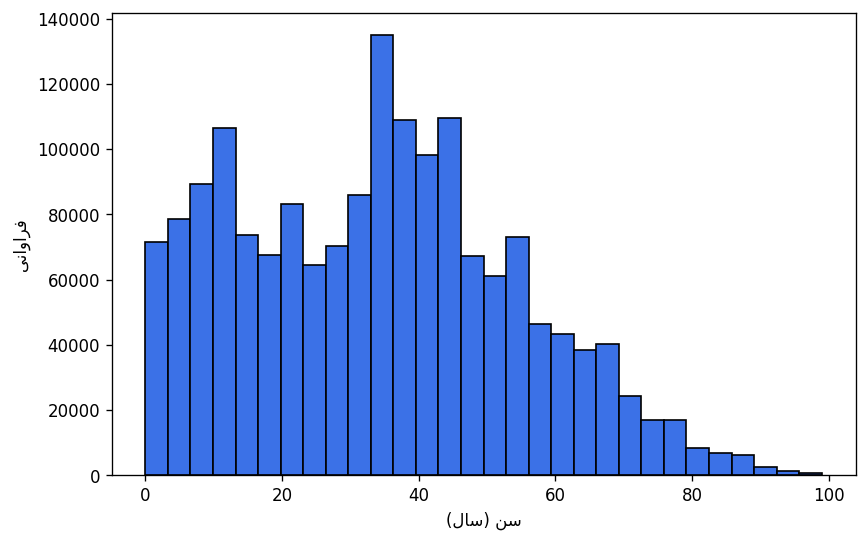

In [72]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df['Age'].dropna(), bins=30, color="#3B71E7", edgecolor='black')
ax.set_xlabel(farsi("سن (سال)"))
ax.set_ylabel(farsi("فراوانی"))
plt.show()

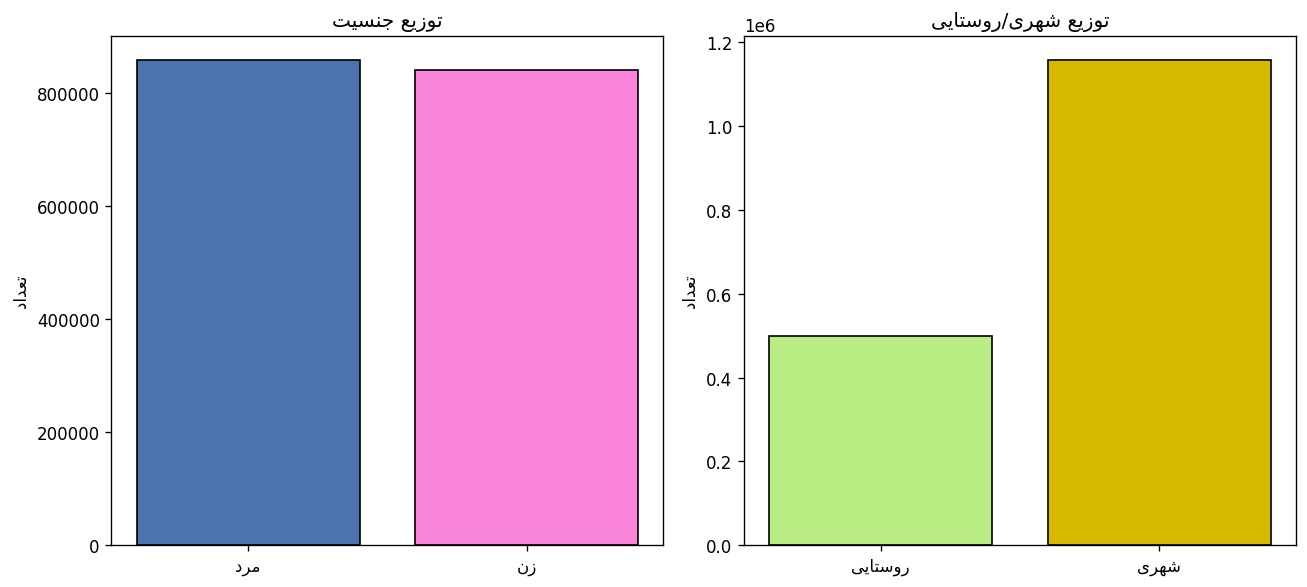

In [73]:
fig, axes = plt.subplots(1,2, figsize=(11,5))

a = df['GenderId'].value_counts().sort_index()
axes[0].bar([farsi("مرد"), farsi("زن")], a.values, color=['#4C72B0',"#F985DA"], edgecolor='black')
axes[0].set_title(farsi("توزیع جنسیت"))
axes[0].set_ylabel(farsi("تعداد"))

b = df['isurban'].value_counts(dropna=True).sort_index()
axes[1].bar([farsi("روستایی"), farsi("شهری")], b.values, color=["#B9ED84","#D7BA00"], edgecolor='black')
axes[1].set_title(farsi("توزیع شهری/روستایی"))
axes[1].set_ylabel(farsi("تعداد"))

plt.tight_layout()
plt.show()

In [74]:
print(f"Urban: {(df['isurban'].mean()*100)}%")

Urban: 69.81879244035272%


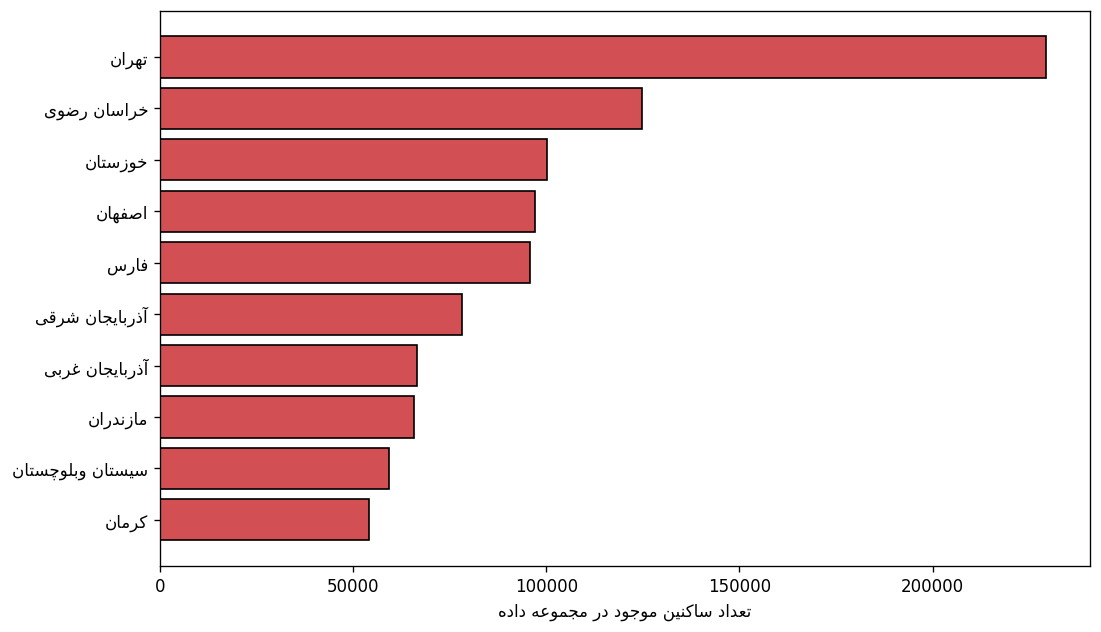

In [75]:
fig, ax = plt.subplots(figsize=(10,6))

population = df['SabteAhval_provincename'].value_counts().head(10)

city_names = []
for city in population.index[::-1]:
    city_names.append(farsi(city))

ax.barh(city_names, population.values[::-1], color="#D25054", edgecolor='black')
ax.set_xlabel(farsi("تعداد ساکنین موجود در مجموعه داده"))

plt.show()

C:\Users\OverGame\AppData\Local\Temp\ipykernel_24180\1220618572.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  male_avg = male.groupby('AgeGroup')['CardPerMonth_1402'].mean()
C:\Users\OverGame\AppData\Local\Temp\ipykernel_24180\1220618572.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  female_avg = female.groupby('AgeGroup')['CardPerMonth_1402'].mean()


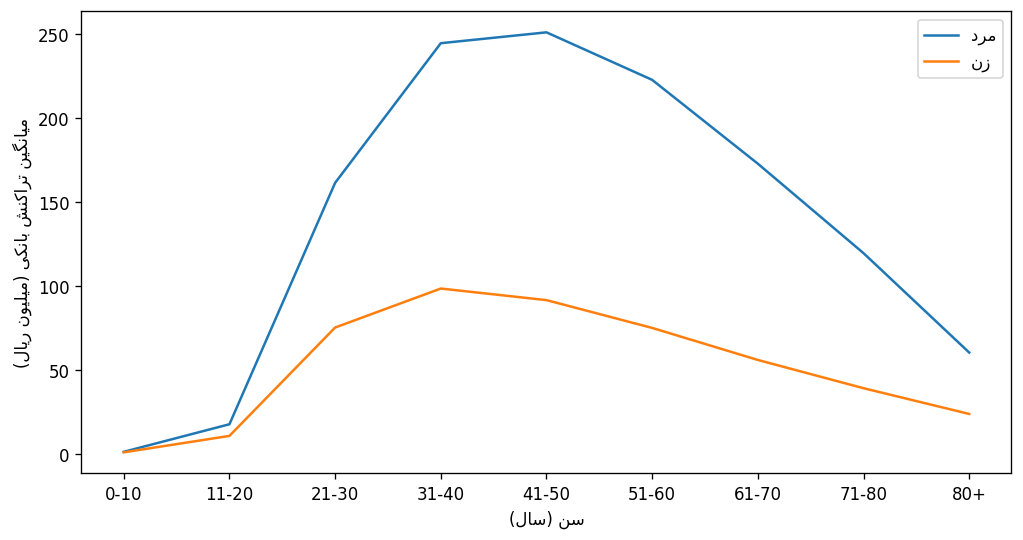

In [76]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,10,20,30,40,50,60,70,80,100], labels=['0-10','11-20','21-30','31-40','41-50','51-60','61-70','71-80','80+'])

male = df[df['GenderId'] == 1]
female = df[df['GenderId'] == 2]

male_avg = male.groupby('AgeGroup')['CardPerMonth_1402'].mean()
female_avg = female.groupby('AgeGroup')['CardPerMonth_1402'].mean()

plt.figure(figsize=(10,5))
plt.plot(male_avg.index.astype(str), male_avg.values / 1000000, label=farsi("مرد"))
plt.plot(female_avg.index.astype(str), female_avg.values / 1000000, label=farsi("زن"))

plt.xlabel(farsi("سن (سال)"))
plt.ylabel(farsi("میانگین تراکنش بانکی (میلیون ریال)"))
plt.legend()

plt.show()

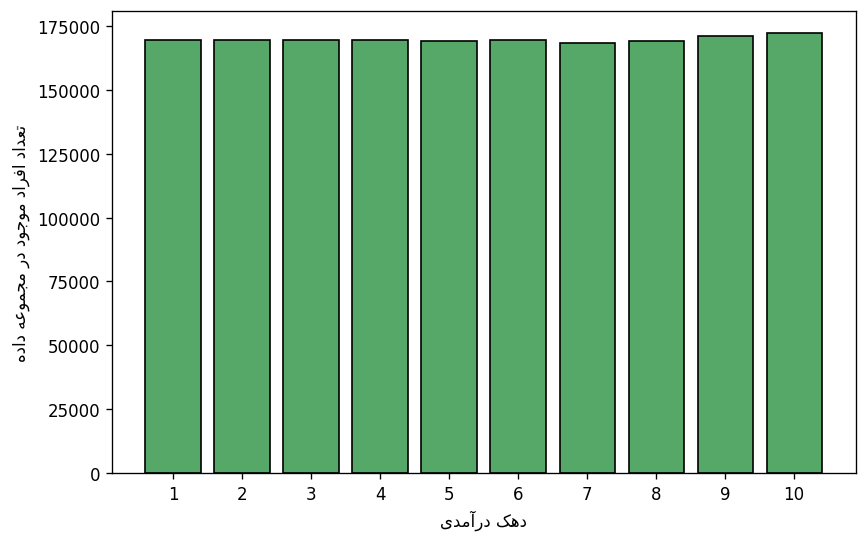

In [77]:
df_dahak = df['Decile'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(df_dahak.index, df_dahak.values, color='#55A868', edgecolor='black')
ax.set_xlabel(farsi("دهک درآمدی"))
ax.set_ylabel(farsi("تعداد افراد موجود در مجموعه داده"))
ax.set_xticks(range(1,11))

plt.show()

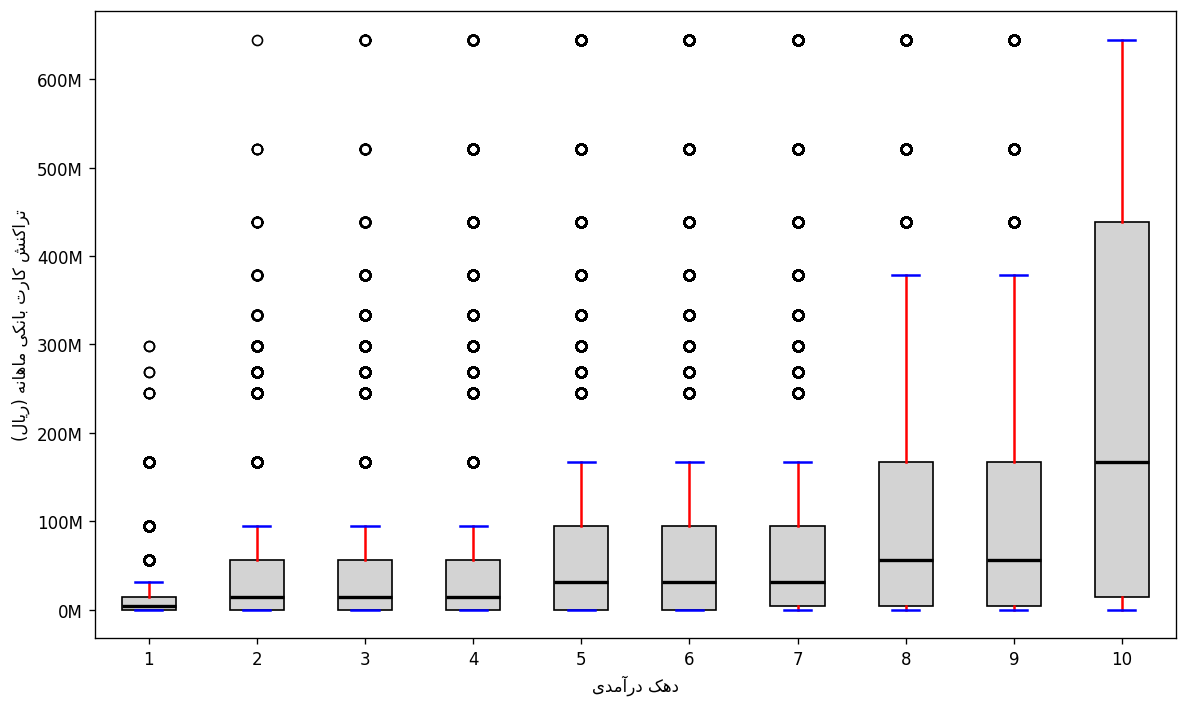

In [78]:
import matplotlib.ticker as mticker

def millions_formatter(x, pos):
    val = x/1e6
    if val.is_integer():
        return f'{int(val)}M'
    return f'{val:.1f}M'

fig, ax = plt.subplots(figsize=(10,6))
upper = df['CardPerMonth_1402'].quantile(0.97)
data_by_decile = [df.loc[df['Decile']==d, 'CardPerMonth_1402'].dropna().clip(upper=upper) for d in range(1,11)]
bp = ax.boxplot(data_by_decile, tick_labels=[str(d) for d in range(1,11)], patch_artist=True,
                 whiskerprops=dict(color='red', linewidth=1.5, linestyle='-'),
                 capprops=dict(color='blue', linewidth=1.5),
                 boxprops=dict(facecolor='lightgray'),
                 medianprops=dict(color='black', linewidth=2))

ax.set_xlabel(farsi("دهک درآمدی"))
ax.set_ylabel(farsi("تراکنش کارت بانکی ماهانه (ریال)"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))

plt.tight_layout()
plt.show()

In [ ]:
# AI is used here:

card_cols = ['CardPerMonth_1398','CardPerMonth_1399','CardPerMonth_1400',
             'CardPerMonth_1401','CardPerMonth_1402']
years = ['1398','1399','1400','1401','1402']

# ================================================================
# INFLATION ADJUSTMENT — Central Bank of Iran (CBI), cbi.ir
# Annual CPI rates, March-to-March (= one Persian Solar year)
# Source: https://cbi.ir/Inflation/Inflation_en.aspx
# ================================================================
inflation_rates = {
    1398: 41.2,   # March 2019 – March 2020
    1399: 47.1,   # March 2020 – March 2021
    1400: 46.2,   # March 2021 – March 2022
    1401: 53.1,   # March 2022 – March 2023
    1402: 47.4,   # March 2023 – March 2024
}

# Cumulative price index, base year 1398 = 1.0
cpi = {1398: 1.0}
for y in [1399, 1400, 1401, 1402]:
    cpi[y] = cpi[y-1] * (1 + inflation_rates[y] / 100)

print("=== CPI deflators (base = 1398) ===")
for y, factor in cpi.items():
    print(f"  {y}: {factor:.4f}  (prices are {factor:.2f}× the 1398 level)")

total_cum = (cpi[1402] - 1) * 100
print(f"\nCumulative price increase 1398→1402: {total_cum:.1f}%")

# Build real (inflation-adjusted) columns in constant 1398 Rials
card_cols  = ['CardPerMonth_1398','CardPerMonth_1399','CardPerMonth_1400',
              'CardPerMonth_1401','CardPerMonth_1402']
years_int  = [1398, 1399, 1400, 1401, 1402]
for col, y in zip(card_cols, years_int):
    df[f'Real_{col}'] = df[col] / cpi[y]

real_cols = [f'Real_{c}' for c in card_cols]
print("\nInflation-adjusted columns created.")


=== CPI deflators (base = 1398) ===
  1398: 1.0000  (prices are 1.00× the 1398 level)
  1399: 1.4710  (prices are 1.47× the 1398 level)
  1400: 2.1506  (prices are 2.15× the 1398 level)
  1401: 3.2926  (prices are 3.29× the 1398 level)
  1402: 4.8533  (prices are 4.85× the 1398 level)

Cumulative price increase 1398→1402: 385.3%

Inflation-adjusted columns created.


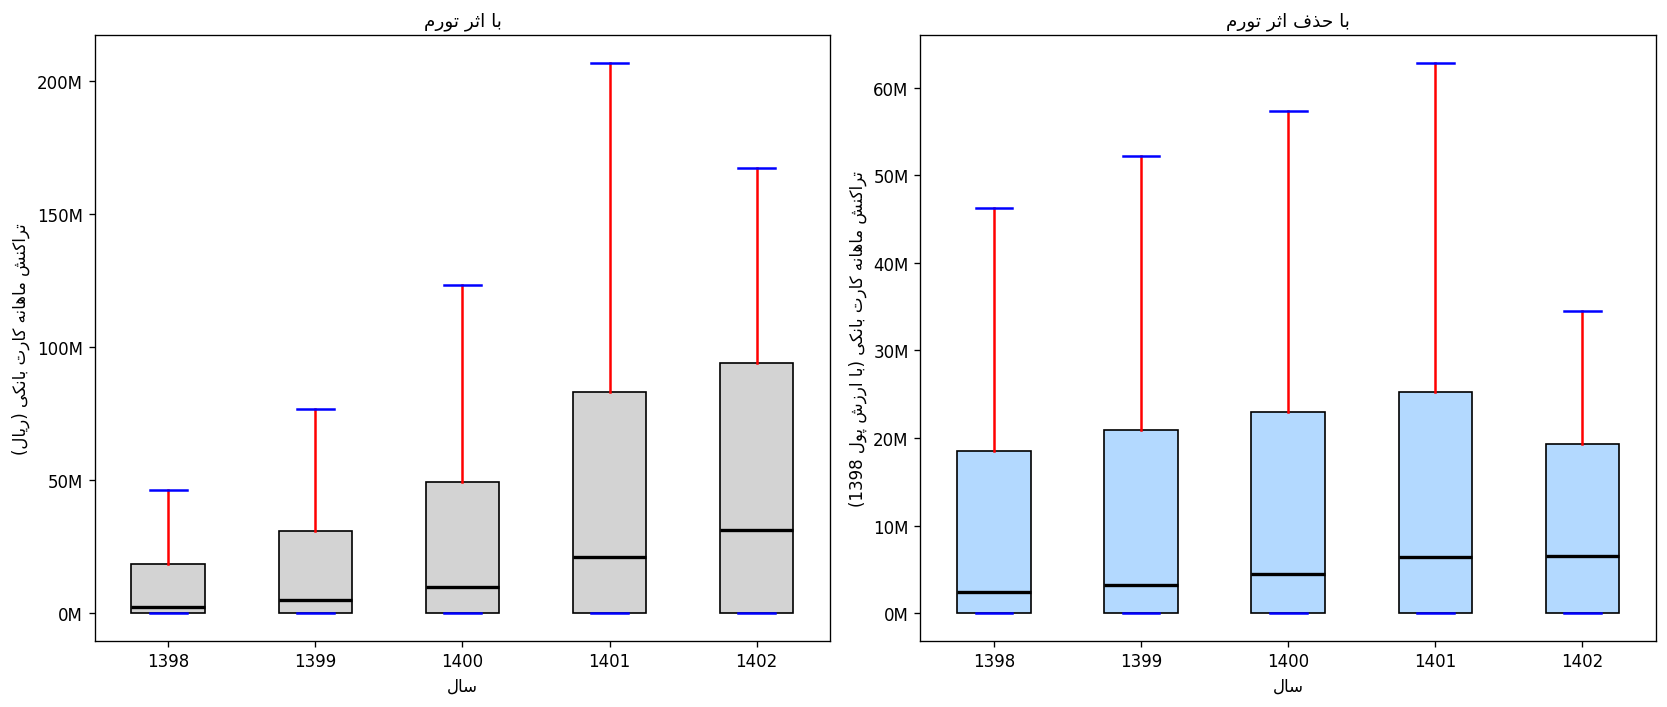

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

upper_nominal = df[card_cols].quantile(0.97).max()
upper_real    = df[real_cols].quantile(0.97).max()

data_nominal = [df[c].dropna().clip(upper=upper_nominal) for c in card_cols]
axes[0].boxplot(data_nominal, tick_labels=years, patch_artist=True,
                whiskerprops=dict(color='red', linewidth=1.5, linestyle='-'),
                capprops=dict(color='blue', linewidth=1.5),
                boxprops=dict(facecolor='lightgray'),
                medianprops=dict(color='black', linewidth=2),
                showfliers=False)
axes[0].set_title(farsi("با اثر تورم"), fontsize=11)
axes[0].set_xlabel(farsi("سال"))
axes[0].set_ylabel(farsi("تراکنش ماهانه کارت بانکی (ریال)"))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))

data_real = [df[c].dropna().clip(upper=upper_real) for c in real_cols]
axes[1].boxplot(data_real, tick_labels=years, patch_artist=True,
                whiskerprops=dict(color='red', linewidth=1.5, linestyle='-'),
                capprops=dict(color='blue', linewidth=1.5),
                boxprops=dict(facecolor='#B3D9FF'),
                medianprops=dict(color='black', linewidth=2),
                showfliers=False)
axes[1].set_title(farsi("با حذف اثر تورم"), fontsize=11)
axes[1].set_xlabel(farsi("سال"))
axes[1].set_ylabel(farsi("تراکنش ماهانه کارت بانکی (با ارزش پول 1398)"))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))

plt.tight_layout()
plt.show()


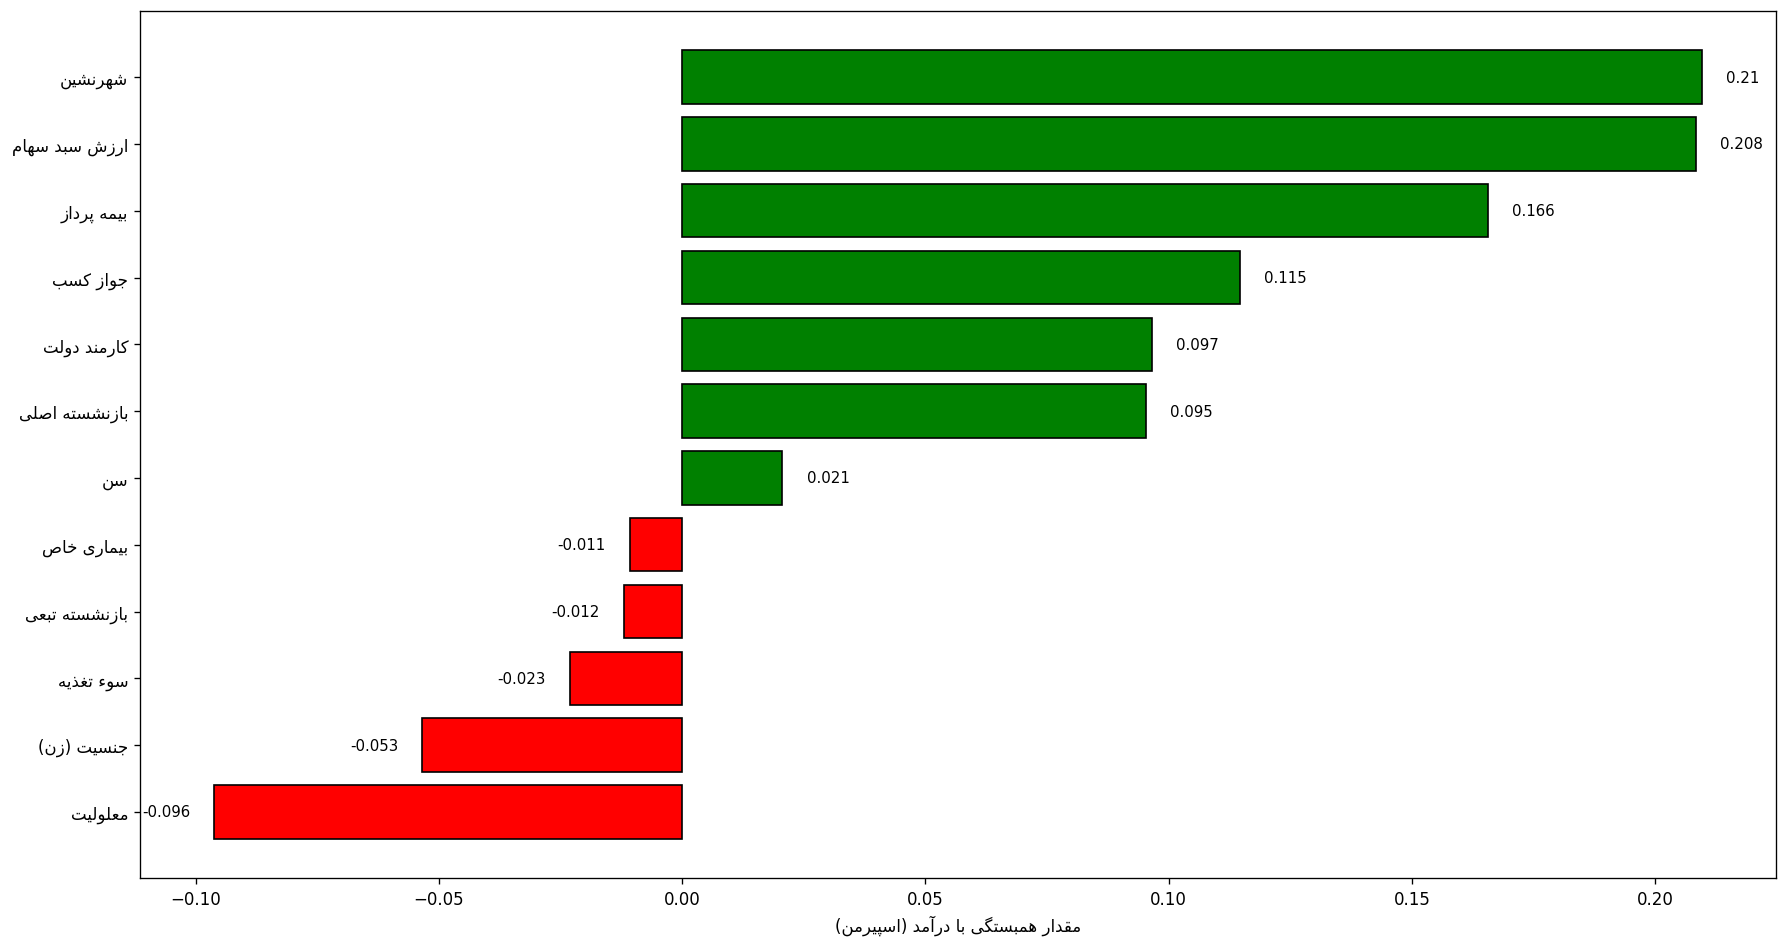

In [ ]:
from scipy.stats import spearmanr

df['GenderFemale'] = (df['GenderId'] == 2).astype(int)

names = [
    'سن',
    'جنسیت (زن)',
    'شهرنشین',
    'ارزش سبد سهام',
    'جواز کسب',
    'کارمند دولت',
    'بیماری خاص',
    'معلولیت',
    'سوء تغذیه',
    'بازنشسته اصلی',
    'بازنشسته تبعی',
    'بیمه پرداز'
]

cols = [
    'Age',
    'GenderFemale',
    'isurban',
    'Bourse_NetPortfoValue',
    'HasMojavezSenfi',
    'ISKarmanddolat_1402',
    'ISBimarKhas',
    'IsMalool',
    'Has_SoeTaghzie',
    'IsRetired_Asli',
    'IsRetired_Tabaie',
    'IsBimePardaz'
]

binary = [
    'ISBimarKhas',
    'IsMalool',
    'Has_SoeTaghzie',
    'Has_Saham_Edalat',
    'HasMojavezSenfi',
    'ISKarmanddolat_1402',
    'IsRetired_Asli',
    'IsRetired_Tabaie',
    'IsBimePardaz'
]

for i in binary:
    df[i] = df[i].fillna(0)

corr = []

for i in cols:
    data = df[['Decile', i]].dropna()
    r, p = spearmanr(data['Decile'], data[i])
    corr.append(r)

table = pd.DataFrame()
table['نام'] = names
table['همبستگی'] = corr

table = table.sort_values('همبستگی')
table = table.reset_index(drop=True)

colors = []

for i in table['همبستگی']:
    if i >= 0:
        colors.append('green')
    else:
        colors.append('red')

labels = []

for i in table['نام']:
    labels.append(farsi(i))

plt.figure(figsize=(15, 8))

plt.barh(labels, table['همبستگی'], color=colors, edgecolor='black')

for i in range(len(table)):
    value = table.loc[i, 'همبستگی']

    if value >= 0:
        plt.text(value + 0.005, i, str(round(value, 3)),
                 va='center', fontsize=9)
    else:
        plt.text(value - 0.005, i, str(round(value, 3)),
                 va='center', ha='right', fontsize=9)

plt.xlabel(farsi("مقدار همبستگی با درآمد (اسپیرمن)"))

plt.tight_layout()
plt.show()

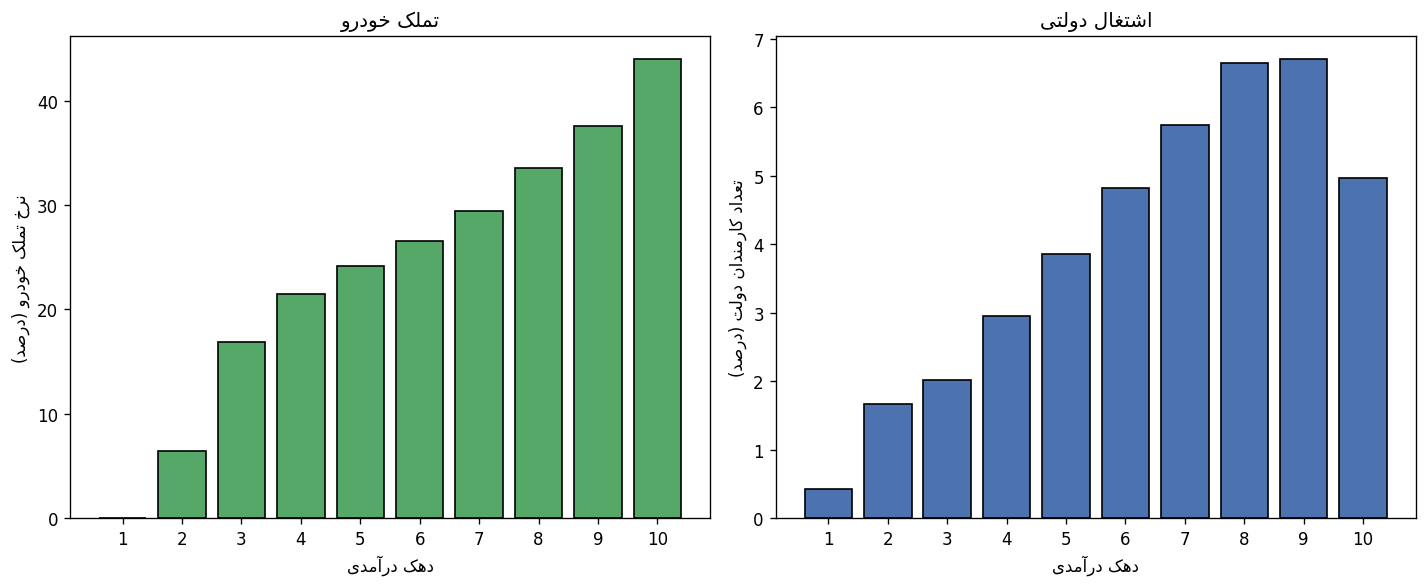

In [82]:
df['HasCar'] = (df['CarsCount'].fillna(0) > 0).astype(int)
fig, axes = plt.subplots(1,2, figsize=(12,5))
car_own = df.groupby('Decile')['HasCar'].mean()*100
axes[0].bar(car_own.index, car_own.values, color='#55A868', edgecolor='black')
axes[0].set_title(farsi("تملک خودرو"))
axes[0].set_xlabel(farsi("دهک درآمدی"))
axes[0].set_ylabel(farsi("نرخ تملک خودرو (درصد)"))
axes[0].set_xticks(range(1,11))

govt = df.groupby('Decile')['ISKarmanddolat_1402'].mean()*100
axes[1].bar(govt.index, govt.values, color='#4C72B0', edgecolor='black')
axes[1].set_title(farsi("اشتغال دولتی"))
axes[1].set_xlabel(farsi("دهک درآمدی"))
axes[1].set_ylabel(farsi("تعداد کارمندان دولت (درصد)"))
axes[1].set_xticks(range(1,11))
plt.tight_layout()
plt.show()

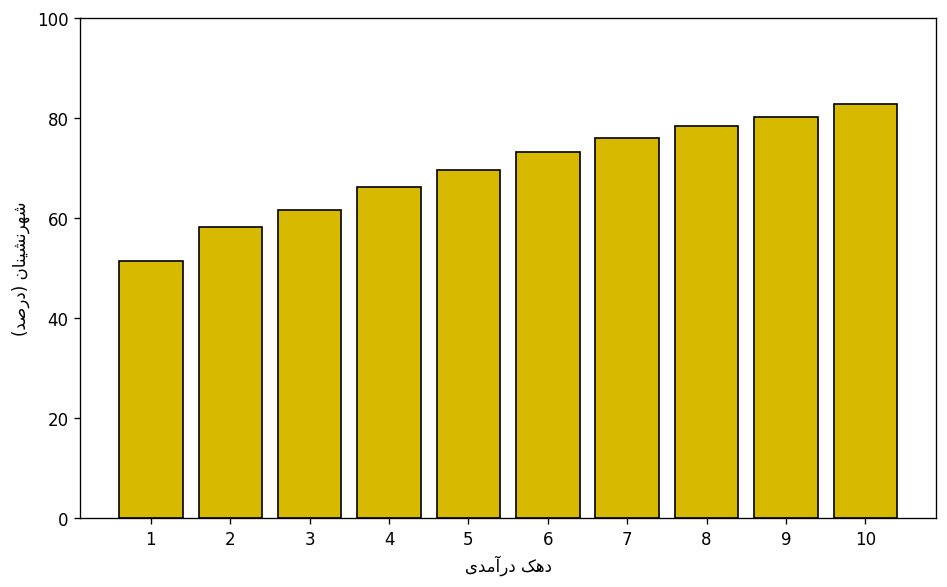

In [83]:
urban_share = df.groupby('Decile')['isurban'].mean()*100
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(urban_share.index, urban_share.values, color='#D7BA00', edgecolor='black')

ax.set_xlabel(farsi("دهک درآمدی"))
ax.set_ylabel(farsi("شهرنشینان (درصد)"))
ax.set_xticks(range(1,11))
ax.set_ylim(0,100)
plt.tight_layout()
plt.show()